In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Data Loading and Initial Inspection

In [11]:
# 1. Load the dataset
df = pd.read_csv('mental_health_prediction_raw_data.csv')

# 2. Display the first few rows to verify correct loading
print("--- First Rows of the Dataset ---")
display(df.head())

# 3. Check data types and overview of non-null counts
print("\n--- Dataset Information and Structure ---")
df.info()

--- First Rows of the Dataset ---


,age,gender,occupation,sleep_hours,sleep_quality,social_media_hours,academic_work_pressure,physical_activity_days,stress_level,anxiety_score,depression_score,work_life_balance,mood_score,concentration_level,social_support,mental_health_condition,severity,treatment
0,15,Female,Student,6.7,8.0,1.0,3.0,4.0,1.0,2.0,1.0,7.0,8.0,6.0,8.0,Normal,Mild,No treatment needed; maintain healthy lifestyl...
1,15,Female,Working Professional,7.8,7.0,1.5,4.0,5.0,3.0,2.0,4.0,8.0,10.0,8.0,6.0,Normal,Mild,No treatment needed; maintain healthy lifestyl...
2,15,Female,Student,7.0,3.0,4.0,6.0,3.0,3.0,10.0,6.0,4.0,4.0,5.0,5.0,Anxiety,Moderate,"Cognitive Behavioral Therapy (CBT), mindfulnes..."
3,15,Female,Both (Part-time work + Study),7.3,2.0,4.6,6.0,2.0,4.0,7.0,8.0,1.0,5.0,4.0,5.0,Anxiety,Moderate,"Cognitive Behavioral Therapy (CBT), mindfulnes..."
4,15,Female,Student,5.0,6.0,4.3,7.0,1.0,7.0,5.0,5.0,1.0,4.0,2.0,6.0,Anxiety,Moderate,"Cognitive Behavioral Therapy (CBT), mindfulnes..."



--- Dataset Information and Structure ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      500 non-null    int64  
 1   gender                   500 non-null    object 
 2   occupation               500 non-null    object 
 3   sleep_hours              485 non-null    float64
 4   sleep_quality            479 non-null    float64
 5   social_media_hours       481 non-null    float64
 6   academic_work_pressure   467 non-null    float64
 7   physical_activity_days   480 non-null    float64
 8   stress_level             472 non-null    float64
 9   anxiety_score            478 non-null    float64
 10  depression_score         478 non-null    float64
 11  work_life_balance        482 non-null    float64
 12  mood_score               480 non-null    float64
 13  concentration_level      479 non-null

Descriptive Statistics and Missing Values

In [12]:
# 1. Statistical summary for numerical columns
print("--- Statistical Summary ---")
display(df.describe().T)

# 2. Calculate missing values and their respective percentages
print("\n--- Missing Values per Column ---")
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

# Create a summary DataFrame for missing data
missing_df = pd.DataFrame({'Total Missing': missing_values, 'Percentage (%)': missing_percent})
# Display only columns that actually have missing values
display(missing_df[missing_df['Total Missing'] > 0])

--- Statistical Summary ---


,count,mean,std,min,25%,50%,75%,max
age,500.0,26.832000,7.735597,15.0,21.0,26.0,32.0,52.0
sleep_hours,485.0,6.769691,1.939245,3.0,5.3,6.7,8.1,12.0
sleep_quality,479.0,4.822547,2.099968,1.0,3.0,5.0,6.0,10.0
social_media_hours,481.0,4.235343,2.002300,0.0,2.6,4.3,5.8,9.3
academic_work_pressure,467.0,6.100642,2.229470,1.0,4.0,6.0,8.0,10.0
physical_activity_days,480.0,1.606250,1.589751,0.0,0.0,1.0,3.0,7.0
stress_level,472.0,5.993644,2.549294,1.0,4.0,6.0,8.0,10.0
anxiety_score,478.0,4.763598,2.338398,1.0,3.0,5.0,7.0,10.0
depression_score,478.0,4.953975,2.437043,1.0,3.0,5.0,7.0,10.0
work_life_balance,482.0,3.784232,2.523717,1.0,2.0,3.0,6.0,10.0



--- Missing Values per Column ---


,Total Missing,Percentage (%)
sleep_hours,15,3.0
sleep_quality,21,4.2
social_media_hours,19,3.8
academic_work_pressure,33,6.6
physical_activity_days,20,4.0
stress_level,28,5.6
anxiety_score,22,4.4
depression_score,22,4.4
work_life_balance,18,3.6
mood_score,20,4.0


In [ ]:
Advanced Data Cleaning (Handling Missing Values)

In [24]:
# 1. Check columns with missing values before treatment
print("--- Missing Values Before Imputation ---")
print(df[['stress_level', 'anxiety_score']].isnull().sum())

# 2. Strategy: Impute numerical missing values using the median
numerical_cols_with_nans = ['stress_level', 'anxiety_score', 'depression_score']
for col in numerical_cols_with_nans:
    if col in df.columns:
        median_value = df[col].median()
        df[col] = df[col].fillna(median_value)

# 3. Verify that the missing values were resolved
print("\n--- Missing Values After Imputation ---")
print(df[['stress_level', 'anxiety_score']].isnull().sum())

--- Missing Values Before Imputation ---
stress_level     28
anxiety_score    22
dtype: int64

--- Missing Values After Imputation ---
stress_level     0
anxiety_score    0
dtype: int64


Categorical Variables Analysis


--- Distribution for Column: gender ---
gender
Non-binary    178
Female        165
Male          157
Name: count, dtype: int64


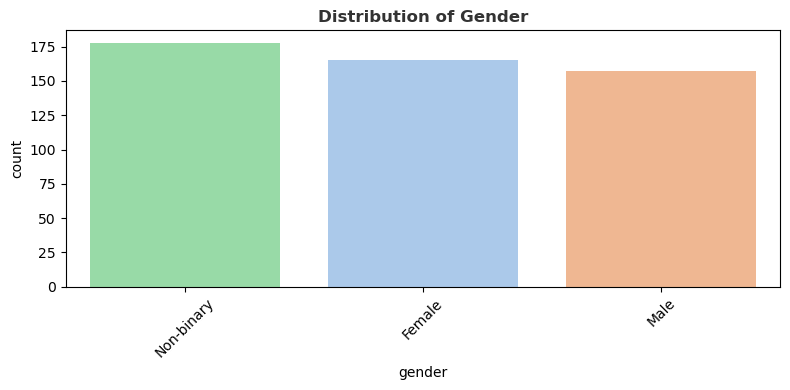


--- Distribution for Column: occupation ---
occupation
Both (Part-time work + Study)    185
Student                          171
Working Professional             144
Name: count, dtype: int64


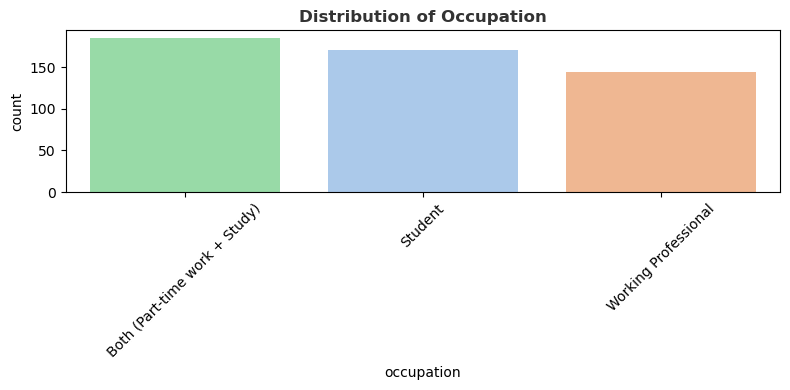


--- Distribution for Column: mental_health_condition ---
mental_health_condition
Normal        125
Anxiety       125
Burnout       125
Depression    125
Name: count, dtype: int64


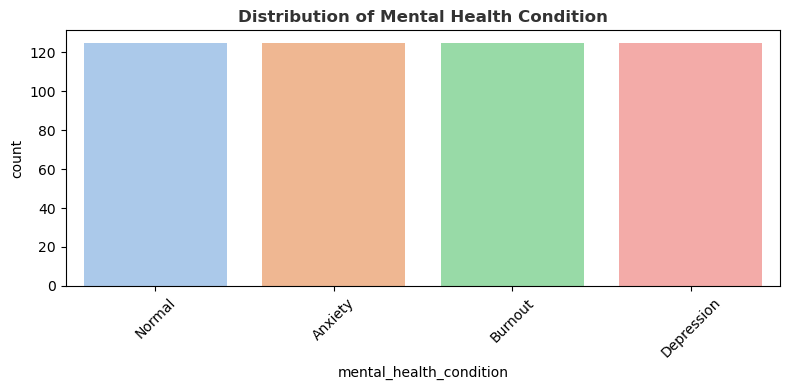


--- Distribution for Column: severity ---
severity
Mild        242
Moderate    229
Severe       29
Name: count, dtype: int64


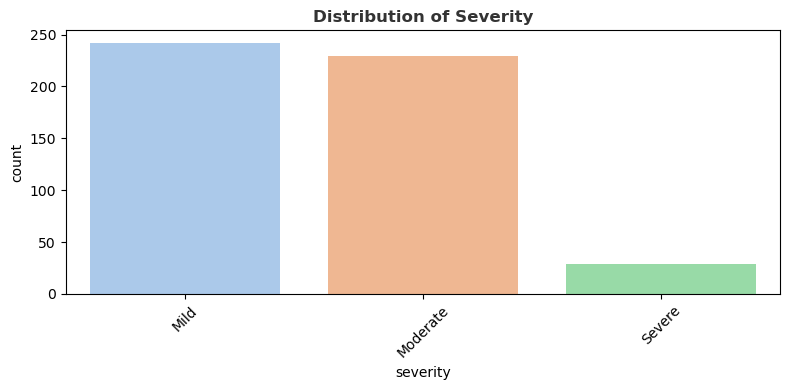

In [16]:
# List of main categorical columns found in the dataset
categorical_cols = ['gender', 'occupation', 'mental_health_condition', 'severity']

for col in categorical_cols:
    if col in df.columns:
        print(f"\n--- Distribution for Column: {col} ---")
        print(df[col].value_counts(dropna=False))
        
        # Get the number of unique categories to avoid palette size errors
        num_categories = df[col].nunique(dropna=False)
        
        plt.figure(figsize=(8, 4))
        
        # Plot using a clean pastel palette limited exactly to the number of categories
        sns.countplot(
            data=df, 
            x=col, 
            order=df[col].value_counts().index, 
            hue=col,            # Assigned to prevent warnings
            legend=False,       # Removes redundant legend box
            palette=sns.color_palette("pastel", n_colors=num_categories) # Beautiful pastel shades
        )
        
        # Title updated to a neutral dark gray color (#333333) instead of red
        plt.title(
            f'Distribution of {col.replace("_", " ").title()}', 
            fontsize=12, 
            fontweight='bold', 
            color='#333333'
        )
        
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

Distribution of Key Numerical Features

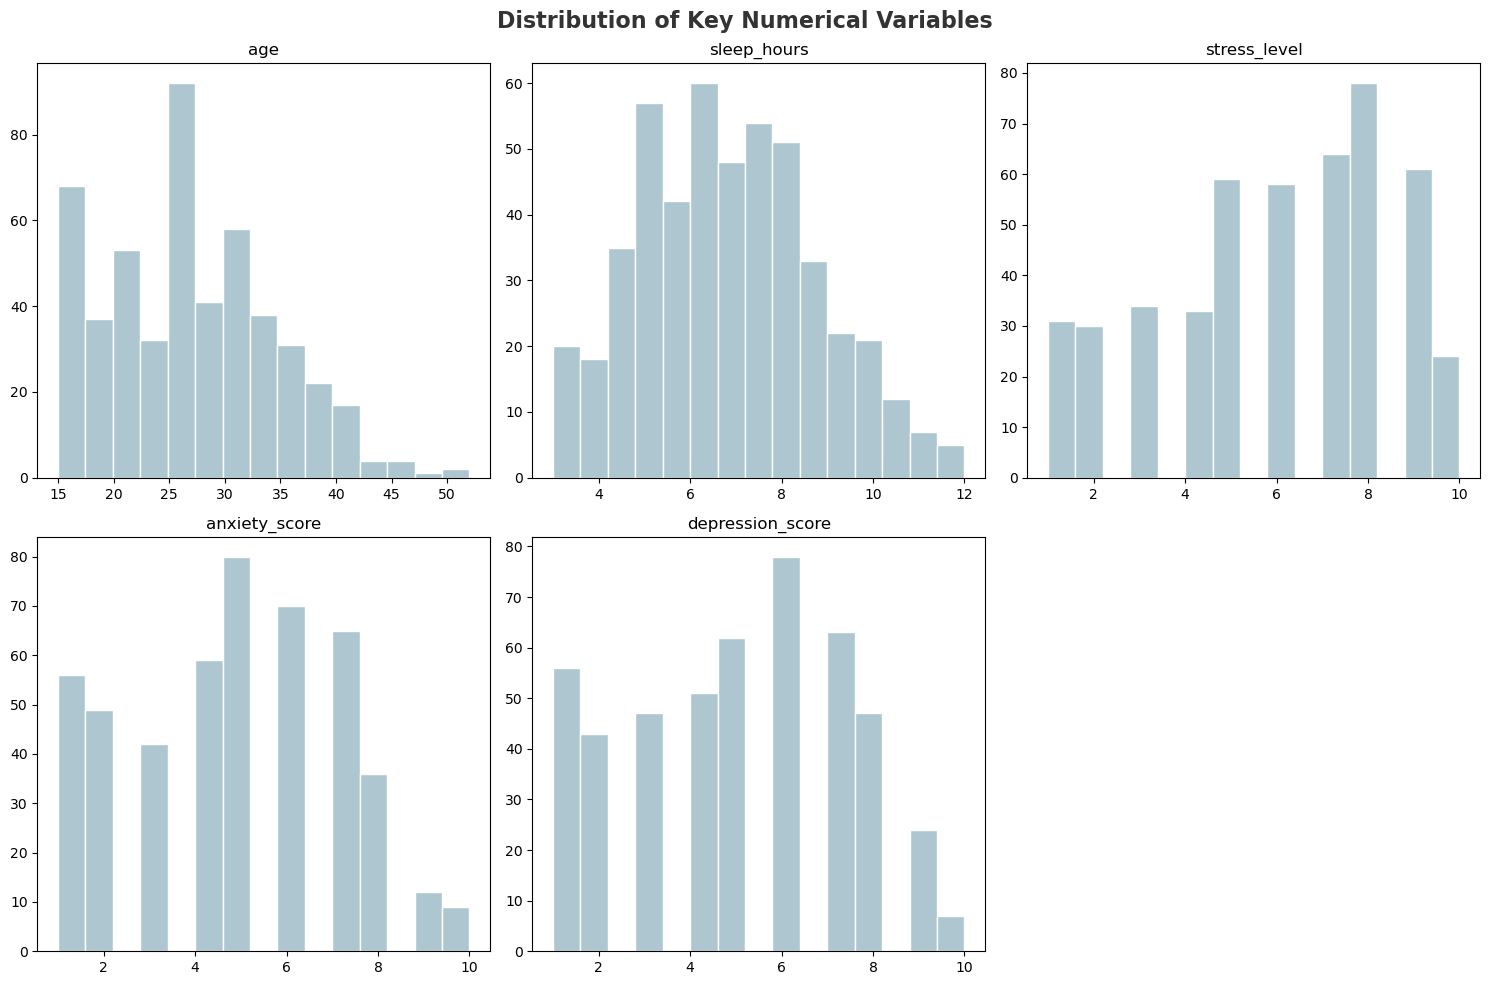

In [18]:
# Select key numerical columns representing mental health and lifestyle indicators
numerical_features = ['age', 'sleep_hours', 'stress_level', 'anxiety_score', 'depression_score']

# Plot histograms using a clean pastel blue and neutral gray borders
df[numerical_features].hist(
    bins=15, 
    figsize=(15, 10), 
    layout=(2, 3), 
    color='#AEC6CF',       # Beautiful soft pastel blue
    edgecolor='#FFFFFF',   # Clean white edges for better separation
    grid=False             # Optional: turned off internal grid for a cleaner look
)

# Title updated to a neutral dark gray color (#333333) to match the dashboard style
plt.suptitle(
    'Distribution of Key Numerical Variables', 
    fontsize=16, 
    fontweight='bold', 
    color='#333333'
)

plt.tight_layout()
plt.show()

Correlation Matrix

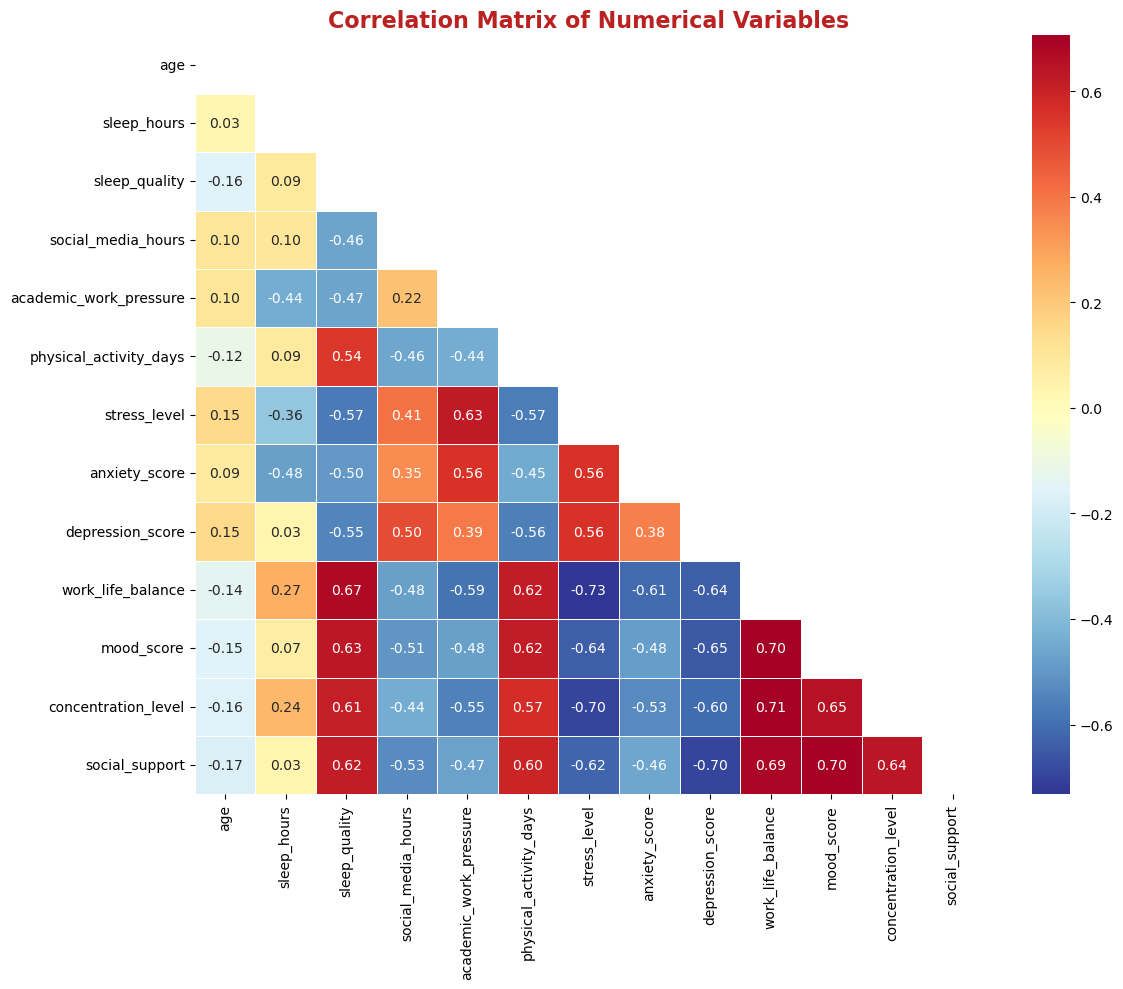

In [19]:
# Select only numerical columns to perform correlation analysis
df_numeric = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 10))

# Generate a mask for the upper triangle to make the heatmap cleaner
mask = np.triu(np.ones_like(df_numeric.corr(), dtype=bool))

# Plot the correlation heatmap using a divergent colormap matching your red/gold tone
sns.heatmap(df_numeric.corr(), annot=True, fmt=".2f", cmap='RdYlBu_r', mask=mask, linewidths=0.5)
plt.title('Correlation Matrix of Numerical Variables', fontsize=16, fontweight='bold', color='#BA2121')
plt.tight_layout()
plt.show()

Risk Profile (Occupation Clustering Analysis)

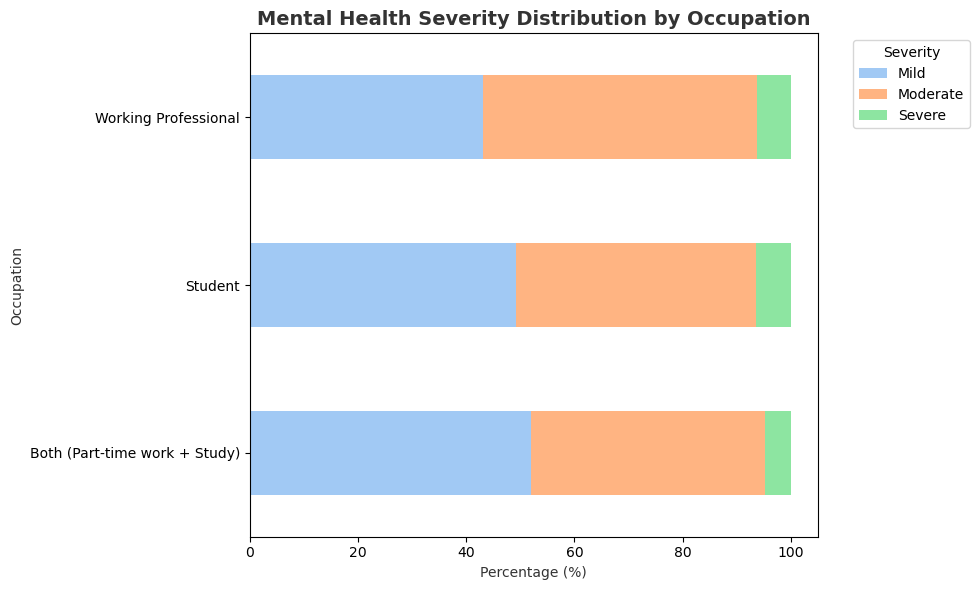

In [20]:
# Cross-tabulate occupation and severity levels
work_severity = pd.crosstab(df['occupation'], df['severity'], normalize='index') * 100

# Plotting with the clean pastel palette
ax = work_severity.plot(
    kind='barh', 
    stacked=True, 
    figsize=(10, 6), 
    color=sns.color_palette("pastel", n_colors=3)
)

# Customizing titles and labels to match the pastel neutral theme
plt.title('Mental Health Severity Distribution by Occupation', fontsize=14, fontweight='bold', color='#333333')
plt.xlabel('Percentage (%)', color='#333333')
plt.ylabel('Occupation', color='#333333')
plt.legend(title='Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Social Media vs. Mental Health (Binned Analysis)

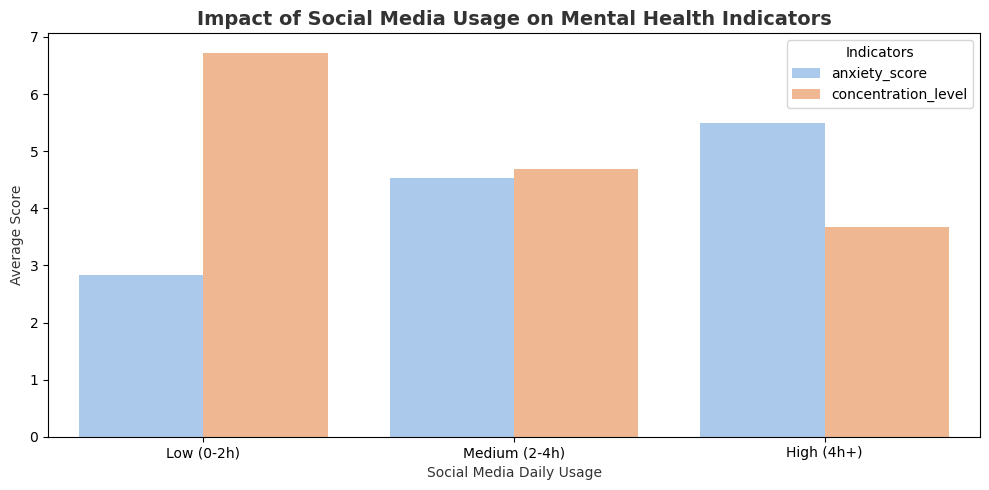

In [21]:
# 1. Create a binned category for social media hours
df['social_media_group'] = pd.cut(
    df['social_media_hours'], 
    bins=[0, 2, 4, np.inf], 
    labels=['Low (0-2h)', 'Medium (2-4h)', 'High (4h+)']
)

# 2. Aggregate anxiety and concentration scores by social media usage
social_media_impact = df.groupby('social_media_group', observed=False)[['anxiety_score', 'concentration_level']].mean().reset_index()

# 3. Plot a side-by-side comparison bar chart using a pastel palette
plt.figure(figsize=(10, 5))
melted_df = social_media_impact.melt(id_vars='social_media_group', var_name='Metric', value_name='Average Score')

sns.barplot(
    data=melted_df, 
    x='social_media_group', 
    y='Average Score', 
    hue='Metric', 
    palette=sns.color_palette("pastel", n_colors=2)
)

plt.title('Impact of Social Media Usage on Mental Health Indicators', fontsize=14, fontweight='bold', color='#333333')
plt.xlabel('Social Media Daily Usage', color='#333333')
plt.ylabel('Average Score', color='#333333')
plt.legend(title='Indicators')
plt.tight_layout()
plt.show()

Outlier Detection (Age Boxplot by Condition)

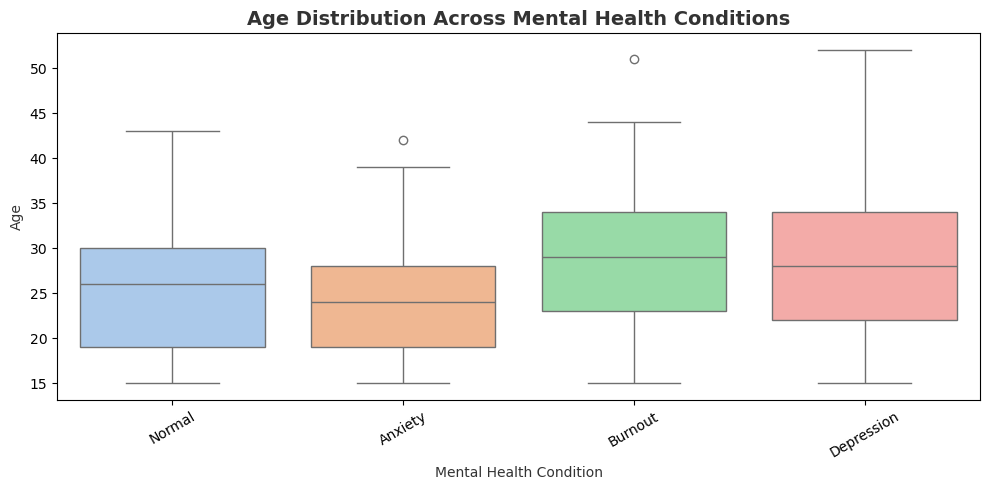

In [23]:
if 'mental_health_condition' in df.columns:
    plt.figure(figsize=(10, 5))
    
    num_conditions = df['mental_health_condition'].nunique()
    
    # Boxplot to reveal age distribution and outliers for each condition
    sns.boxplot(
        data=df, 
        x='mental_health_condition', 
        y='age', 
        hue='mental_health_condition',
        legend=False,
        palette=sns.color_palette("pastel", n_colors=num_conditions)
    )
    
    plt.title('Age Distribution Across Mental Health Conditions', fontsize=14, fontweight='bold', color='#333333')
    plt.xlabel('Mental Health Condition', color='#333333')
    plt.ylabel('Age', color='#333333')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

Feature Engineering (Creating New Insightful Metrics)

In [25]:
# 1. Create a 'Burnout Risk Index' by combining pressure and stress levels
if 'academic_work_pressure' in df.columns and 'stress_level' in df.columns:
    df['burnout_risk_index'] = (df['academic_work_pressure'] + df['stress_level']) / 2

# 2. Create a 'Lifestyle Score' (More activity + better sleep = higher score)
if 'physical_activity_days' in df.columns and 'sleep_quality' in df.columns:
    df['lifestyle_score'] = (df['physical_activity_days'] + df['sleep_quality']) / 2

# Display the newly engineered features
print("--- Newly Engineered Features ---")
display(df[['burnout_risk_index', 'lifestyle_score']].head())

--- Newly Engineered Features ---


,burnout_risk_index,lifestyle_score
0,2.0,6.0
1,3.5,6.0
2,4.5,3.0
3,5.0,2.0
4,7.0,3.5


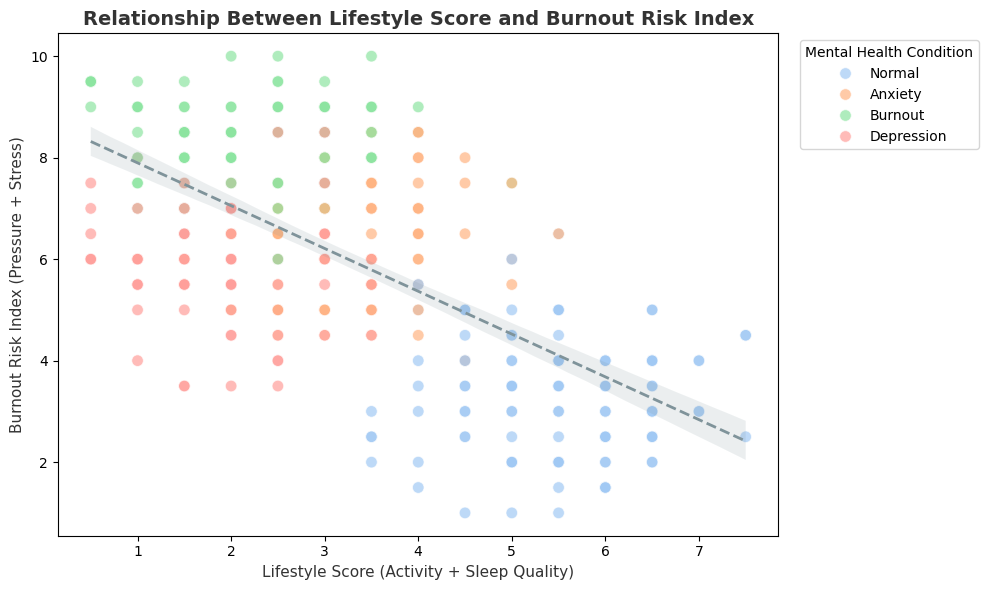

In [27]:
# Ensure the newly created features exist in the dataframe
if 'burnout_risk_index' in df.columns and 'lifestyle_score' in df.columns:
    
    # Set up the plotting style to match a clean portfolio layout
    plt.figure(figsize=(10, 6))
    
    # Get the exact number of unique categories to prevent any palette size errors
    num_conditions = df['mental_health_condition'].nunique(dropna=False)
    
    # Use a scatter plot with alpha transparency to handle dense data points beautifully
    sns.scatterplot(
        data=df,
        x='lifestyle_score',
        y='burnout_risk_index',
        hue='mental_health_condition', # Colors the dots by condition to add a third layer of insight
        palette=sns.color_palette("pastel", n_colors=num_conditions), # Exactly matched to prevent errors
        alpha=0.7,
        s=70 # Size of the data points
    )
    
    # Add a subtle trend line to show the overall direction/correlation cleanly
    sns.regplot(
        data=df,
        x='lifestyle_score',
        y='burnout_risk_index',
        scatter=False, # Do not draw duplicate scatter points
        color='#7F939A', # Soft neutral gray-blue for the line
        line_kws={'linestyle': '--', 'linewidth': 2}
    )
    
    # Customize the labels and clean dark gray title (#333333)
    plt.title('Relationship Between Lifestyle Score and Burnout Risk Index', fontsize=14, fontweight='bold', color='#333333')
    plt.xlabel('Lifestyle Score (Activity + Sleep Quality)', fontsize=11, color='#333333')
    plt.ylabel('Burnout Risk Index (Pressure + Stress)', fontsize=11, color='#333333')
    
    # Adjust the legend position so it doesn't block data points
    plt.legend(title='Mental Health Condition', bbox_to_anchor=(1.02, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()